Данные о симуляции в OpenFoam: \
X = [0,1]\
Y = [0,2] \
Z = [0, 0.01] \
160 ячеек по X, 320 по Y, 1 по Z



In [15]:
import math
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# CSVs:
# - data_points_phi.csv: columns [x, y, phi, t]
# - collocation.csv:  columns [x, y, t]
DATA_CSV = "datasets/data_points_phi.csv"
PHYS_CSV = "datasets/collocation.csv"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32


In [16]:
# Training
LR_PRETRAIN = 1e-3
LR_FULL = 1e-4
PRETRAIN_EPOCHS = 200
FULL_TRAIN_EPOCHS = 1000

BATCH_DATA = 8192
BATCH_PHYS = 2048
NUM_WORKERS = 0

LAMBDA_DATA = 20.0
LAMBDA_PRESSURE_GAUGE = 1.0

PRETRAIN_CKPT_PATH = "checkpoints/model_pretrain.pt"
FULL_CKPT_PATH = "checkpoints/model_full.pt"

# Separate sharpness for supervised pretrain and full PINN stage
S_PRETRAIN = 5.0
S_FULL_START = 10.0
S_FULL_END = 40.0
S_FULL_RAMP_EPOCHS = 400



In [17]:
# =========================
# PHYSICAL DOMAIN
# =========================
# These bounds define the physical domain used by the PDE and hard BC ansatz.
X_MIN, X_MAX = 0.0, 1.0
Y_MIN, Y_MAX = 0.0, 2.0
T_MIN, T_MAX = 0.0, 3.0

# Fixed pressure gauge point used to remove the constant-pressure ambiguity.
P_GAUGE_X = 0.5 * (X_MIN + X_MAX)
P_GAUGE_Y = 0.5 * (Y_MIN + Y_MAX)
P_GAUGE_T = T_MIN

# Normalize inputs to [-1, 1] before passing them to the MLP.
# Residuals are still differentiated w.r.t. physical coordinates, so
# autograd applies the chain rule automatically.
X_CENTER = 0.5 * (X_MIN + X_MAX)
Y_CENTER = 0.5 * (Y_MIN + Y_MAX)
T_CENTER = 0.5 * (T_MIN + T_MAX)

X_HALF_RANGE = 0.5 * (X_MAX - X_MIN)
Y_HALF_RANGE = 0.5 * (Y_MAX - Y_MIN)
T_HALF_RANGE = 0.5 * (T_MAX - T_MIN)

g_x = 0.0
g_y = 9.80

# =========================
# FLUID PROPERTIES
# =========================
# phi = +1 liquid, phi = -1 gas
rho_l = 1000.0
rho_g = 100.0

# mu - dynamic viscosity
mu_l = 10.0
mu_g = 1.0

# surface tension
sigma = 24.5
EPS_NORM = 1e-6  # for normals

# =========================
# REFERENCE SCALES FOR NONDIMENSIONAL MOMENTUM
# =========================
# Use gravity-based scales so that inertial and gravity terms are comparable.
L_REF = X_MAX - X_MIN
RHO_REF = rho_l
MU_REF = mu_l
U_REF = math.sqrt(abs(g_y) * L_REF) if abs(g_y) > 0.0 else 1.0
T_REF = L_REF / U_REF
P_REF = RHO_REF * U_REF**2

RE_REF = RHO_REF * U_REF * L_REF / MU_REF
WE_REF = RHO_REF * U_REF**2 * L_REF / sigma
G_X_REF = g_x * L_REF / (U_REF**2)
G_Y_REF = g_y * L_REF / (U_REF**2)

print(
    f"Reference scales: L={L_REF:.4f}, U={U_REF:.4f}, T={T_REF:.4f}, P={P_REF:.4f}, "
    f"Re={RE_REF:.4f}, We={WE_REF:.4f}, Gx={G_X_REF:.4f}, Gy={G_Y_REF:.4f}"
)



Reference scales: L=1.0000, U=3.1305, T=0.3194, P=9800.0000, Re=313.0495, We=400.0000, Gx=0.0000, Gy=1.0000


In [34]:
class DataPoints(Dataset):
    """Supervised data points: (x,y,t) -> phi."""
    def __init__(self, csv_path: str):
        df = pd.read_csv(csv_path)
        for c in ["x", "y", "t", "phi"]:
            if c not in df.columns:
                raise ValueError(f"Missing column '{c}' in {csv_path}. Columns: {df.columns}")
        self.xyt = df[["x", "y", "t"]].to_numpy(dtype=np.float32)
        self.phi = df["phi"].to_numpy(dtype=np.float32)[:, None]

    def __len__(self):
        return self.xyt.shape[0]

    def __getitem__(self, idx):
        return self.xyt[idx], self.phi[idx]


class PhysicsPoints(Dataset):
    """Collocation points for PDE residuals: (x,y,t)."""
    def __init__(self, csv_path: str):
        df = pd.read_csv(csv_path)
        for c in ["x", "y", "t"]:
            if c not in df.columns:
                raise ValueError(f"Missing column '{c}' in {csv_path}. Columns: {df.columns}")
        self.xyt = df[["x", "y", "t"]].to_numpy(dtype=np.float32)

    def __len__(self):
        return self.xyt.shape[0]

    def __getitem__(self, idx):
        return self.xyt[idx]


class AdaptiveSwish(nn.Module):
    """swish_beta(x) = x * sigmoid(beta * x), beta is learnable (scalar)."""
    def __init__(self, init_beta: float = 1.0):
        super().__init__()
        self.beta = nn.Parameter(torch.tensor(float(init_beta)))

    def forward(self, x):
        return x * torch.sigmoid(self.beta * x)


class MLP(nn.Module):
    def __init__(self, in_dim=3, out_dim=4, hidden=100, depth=6):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), AdaptiveSwish(1.0)]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), AdaptiveSwish(1.0)]
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, xyt):
        return self.net(xyt)


# =========================
# Coordinate normalization
# =========================

def normalize_xyt(xyt: torch.Tensor) -> torch.Tensor:
    center = xyt.new_tensor([X_CENTER, Y_CENTER, T_CENTER])
    half_range = xyt.new_tensor([X_HALF_RANGE, Y_HALF_RANGE, T_HALF_RANGE])
    return (xyt - center) / half_range


# =========================
# Physics: mixture laws
# =========================

def mixture_rho(phi: torch.Tensor) -> torch.Tensor:
    return 0.5 * ((1.0 + phi) * rho_l + (1.0 - phi) * rho_g)

def mixture_mu(phi: torch.Tensor) -> torch.Tensor:
    return 0.5 * ((1.0 + phi) * mu_l + (1.0 - phi) * mu_g)


def mixture_rho_nd(phi: torch.Tensor) -> torch.Tensor:
    return mixture_rho(phi) / RHO_REF


def mixture_mu_nd(phi: torch.Tensor) -> torch.Tensor:
    return mixture_mu(phi) / MU_REF


# =========================
# Autodiff helpers
# =========================

def grad(outputs: torch.Tensor, inputs: torch.Tensor) -> torch.Tensor:
    return torch.autograd.grad(
        outputs,
        inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]


# =========================
# Forward + hard BC as in paper (computed on physical x,y)
# =========================

def model_fields(model: nn.Module, xyt: torch.Tensor):
    """
    xyt: (N,3) in PHYSICAL coordinates.
    The MLP itself sees normalized coordinates, while PDE residuals still use
    derivatives w.r.t. physical coordinates through autograd.
    returns: u, v, p, alpha_sdf
    """
    xyt_norm = normalize_xyt(xyt)
    out = model(xyt_norm)
    u_raw = out[:, 0:1]
    v_raw = out[:, 1:2]
    p = out[:, 2:3]
    alpha = out[:, 3:4]

    # Hard no-slip BC via ansatz (x in [0,1], y in [0,2]):
    # l_u = sin(pi x) * sin(pi y/2)
    # l_v = sin(pi y/2)
    x = xyt[:, 0:1]
    y = xyt[:, 1:2]
    l_u = torch.sin(math.pi * x) * torch.sin(math.pi * y / 2.0)
    l_v = torch.sin(math.pi * y / 2.0)

    u = l_u * u_raw
    v = l_v * v_raw

    return u, v, p, alpha


def pressure_gauge_loss(model: nn.Module) -> torch.Tensor:
    gauge_point = torch.tensor(
        [[P_GAUGE_X, P_GAUGE_Y, P_GAUGE_T]],
        device=DEVICE,
        dtype=DTYPE,
    )
    _, _, p_anchor, _ = model_fields(model, gauge_point)
    p_anchor_nd = p_anchor / P_REF
    return torch.mean(p_anchor_nd ** 2)




In [35]:
def get_phys_weights(epoch):
    """
    Returns (w_div, w_adv, w_mom, w_eik, lambda_phys_global)
    for the full PINN stage after supervised pretraining.
    """
    if epoch <= 150:
        return 1.0, 1.0, 0.0, 0.0, 0.05

    if epoch <= 500:
        return 1.0, 1.0, 0.5, 0.0, 0.10

    if epoch <= 800:
        return 1.0, 1.0, 1.0, 0.0, 0.20

    return 1.0, 1.0, 1.0, 0.1, 0.30


In [36]:
torch.manual_seed(0)
np.random.seed(0)
os.makedirs("checkpoints", exist_ok=True)

data_ds = DataPoints(DATA_CSV)
phys_ds = PhysicsPoints(PHYS_CSV)

data_loader = DataLoader(data_ds, batch_size=BATCH_DATA, shuffle=True, drop_last=True, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=False)
phys_loader = DataLoader(phys_ds, batch_size=BATCH_PHYS, shuffle=True, drop_last=True, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=False)

def build_model():
    return MLP(in_dim=3, out_dim=4, hidden=100, depth=6).to(DEVICE).to(DTYPE)

def build_optimizer(model: nn.Module, lr: float):
    return torch.optim.Adam(model.parameters(), lr=lr)

def load_checkpoint_weights(model: nn.Module, ckpt_path: str):
    state = torch.load(ckpt_path, map_location=DEVICE)
    if isinstance(state, dict) and "model_state_dict" in state:
        model.load_state_dict(state["model_state_dict"])
    elif isinstance(state, dict):
        model.load_state_dict(state)
    else:
        raise ValueError(f"Unexpected checkpoint format: {ckpt_path}")
    return model



In [37]:
def residuals(model: nn.Module, xyt: torch.Tensor, s_val: float):
    """
    Compute residuals at physics points in physical coordinates.
    The network sees normalized coordinates inside model_fields(), while all
    derivatives here remain physical because xyt itself is physical.

    Momentum terms are assembled in nondimensional form using the reference
    scales defined above. This reduces the stiffness caused by raw physical
    coefficients rho, mu, g, and sigma.
    """
    xyt = xyt.requires_grad_(True)

    u, v, p, alpha = model_fields(model, xyt)

    phi = torch.tanh(float(s_val) * alpha)
    delta = 1.0 - phi**2  # = 1 - tanh^2(s alpha)

    # Dimensionless mixture properties
    rho_nd = mixture_rho_nd(phi)
    mu_nd = mixture_mu_nd(phi)

    # First derivatives in physical coordinates.
    u_grad = grad(u, xyt)   # du/dx, du/dy, du/dt
    v_grad = grad(v, xyt)
    p_grad = grad(p, xyt)
    a_grad = grad(alpha, xyt)

    u_x, u_y, u_t = u_grad[:, 0:1], u_grad[:, 1:2], u_grad[:, 2:3]
    v_x, v_y, v_t = v_grad[:, 0:1], v_grad[:, 1:2], v_grad[:, 2:3]
    p_x, p_y = p_grad[:, 0:1], p_grad[:, 1:2]
    a_x, a_y, a_t = a_grad[:, 0:1], a_grad[:, 1:2], a_grad[:, 2:3]

    # Divergence residual
    r_div = u_x + v_y

    # Level-set transport residual
    r_adv = a_t + u * a_x + v * a_y

    # Eikonal residual (SDF constraint)
    grad_a_norm = torch.sqrt(a_x**2 + a_y**2 + 1e-12)
    r_eik = grad_a_norm - 1.0

    n_x = a_x / (grad_a_norm + EPS_NORM)
    n_y = a_y / (grad_a_norm + EPS_NORM)

    n_x_grad = grad(n_x, xyt)
    n_y_grad = grad(n_y, xyt)

    dnxx_dx_nd = L_REF * n_x_grad[:, 0:1]
    dnyy_dy_nd = L_REF * n_y_grad[:, 1:2]
    kappa_nd = dnxx_dx_nd + dnyy_dy_nd

    f_st_x_nd = (1.0 / WE_REF) * kappa_nd * n_x * delta
    f_st_y_nd = (1.0 / WE_REF) * kappa_nd * n_y * delta

    u_nd = u / U_REF
    v_nd = v / U_REF

    u_x_nd = (L_REF / U_REF) * u_x
    u_y_nd = (L_REF / U_REF) * u_y
    u_t_nd = (T_REF / U_REF) * u_t
    v_x_nd = (L_REF / U_REF) * v_x
    v_y_nd = (L_REF / U_REF) * v_y
    v_t_nd = (T_REF / U_REF) * v_t
    p_x_nd = (L_REF / P_REF) * p_x
    p_y_nd = (L_REF / P_REF) * p_y

    Dxx_nd = u_x_nd
    Dyy_nd = v_y_nd
    Dxy_nd = 0.5 * (u_y_nd + v_x_nd)

    term_xx_nd = 2.0 * mu_nd * Dxx_nd
    term_xy_nd = 2.0 * mu_nd * Dxy_nd
    term_yy_nd = 2.0 * mu_nd * Dyy_nd

    term_xx_nd_grad = grad(term_xx_nd, xyt)
    term_xy_nd_grad = grad(term_xy_nd, xyt)
    term_yy_nd_grad = grad(term_yy_nd, xyt)

    visc_x_nd = L_REF * term_xx_nd_grad[:, 0:1] + L_REF * term_xy_nd_grad[:, 1:2]
    visc_y_nd = L_REF * term_xy_nd_grad[:, 0:1] + L_REF * term_yy_nd_grad[:, 1:2]

    adv_u_nd = u_t_nd + u_nd * u_x_nd + v_nd * u_y_nd
    adv_v_nd = v_t_nd + u_nd * v_x_nd + v_nd * v_y_nd

    r_mom_u = rho_nd * adv_u_nd + p_x_nd - (1.0 / RE_REF) * visc_x_nd - rho_nd * G_X_REF - f_st_x_nd
    r_mom_v = rho_nd * adv_v_nd + p_y_nd - (1.0 / RE_REF) * visc_y_nd - rho_nd * G_Y_REF - f_st_y_nd

    return {
        "r_div": r_div,
        "r_adv": r_adv,
        "r_eik": r_eik,
        "r_mom_u": r_mom_u,
        "r_mom_v": r_mom_v,
        "phi": phi,
        "alpha": alpha,
        "u": u,
        "v": v,
        "p": p,
        "rho_nd": rho_nd,
        "mu_nd": mu_nd,
    }




In [24]:
from itertools import cycle
from tqdm.auto import tqdm
import torch

s_pretrain = S_PRETRAIN
s_pretrain_tensor = torch.tensor(s_pretrain, device=DEVICE, dtype=DTYPE)

# -------- EMA settings for the full PINN stage --------
EMA_BETA = 0.99
EMA_EPS = 1e-8
EMA_WARMUP_STEPS = 200

def get_s_full(epoch: int) -> float:
    if S_FULL_RAMP_EPOCHS <= 0:
        return S_FULL_END
    ramp = min(max((epoch - 1) / S_FULL_RAMP_EPOCHS, 0.0), 1.0)
    return S_FULL_START + (S_FULL_END - S_FULL_START) * ramp

def make_pretrain_history():
    return {
        "epoch": [],
        "loss": [],
        "loss_data": [],
        "s": [],
    }

def make_full_history():
    return {
        "epoch": [],
        "loss": [],
        "loss_data": [],
        "loss_phys": [],
        "loss_gauge": [],
        "s": [],
        "L_div": [],
        "L_adv": [],
        "L_mom": [],
        "L_eik": [],
        "ema_div": [],
        "ema_adv": [],
        "ema_mom": [],
        "ema_eik": [],
    }

def save_checkpoint(model: nn.Module, ckpt_path: str, epoch: int, stage: str):
    torch.save(
        {
            "epoch": epoch,
            "stage": stage,
            "model_state_dict": model.state_dict(),
        },
        ckpt_path,
    )
    print(f"Saved checkpoint: {ckpt_path}")

def train_pretrain(model: nn.Module, opt: torch.optim.Optimizer, epochs: int):
    history = make_pretrain_history()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_loss_data = 0.0

        with tqdm(
            data_loader,
            desc=f"Pretrain {epoch}/{epochs}",
            total=len(data_loader),
            dynamic_ncols=True,
            leave=False,
        ) as pbar:
            for (xyt_d_np, phi_np) in pbar:
                xyt_d = xyt_d_np.to(DEVICE, dtype=DTYPE)
                phi_true = phi_np.to(DEVICE, dtype=DTYPE)

                _, _, _, alpha_d = model_fields(model, xyt_d)
                phi_pred = torch.tanh(s_pretrain_tensor * alpha_d)
                loss_data = torch.mean((phi_pred - phi_true) ** 2)
                loss = LAMBDA_DATA * loss_data

                opt.zero_grad(set_to_none=True)
                loss.backward()
                opt.step()

                running_loss += float(loss.item())
                running_loss_data += float(loss_data.item())

                pbar.set_postfix(
                    loss=f"{loss.item():.4e}",
                    loss_data=f"{loss_data.item():.4e}",
                )

        n_batches = len(data_loader)
        history["epoch"].append(epoch)
        history["loss"].append(running_loss / n_batches)
        history["loss_data"].append(running_loss_data / n_batches)
        history["s"].append(s_pretrain)

        if epoch % 25 == 0 or epoch == 1:
            print(
                f"pretrain_epoch={epoch:5d} "
                f"loss={history['loss'][-1]:.4e} "
                f"loss_data={history['loss_data'][-1]:.4e}"
            )

    save_checkpoint(model, PRETRAIN_CKPT_PATH, epochs, stage="pretrain")
    return history



In [25]:
model = build_model()
opt = build_optimizer(model, lr=LR_PRETRAIN)
pretrain_history = train_pretrain(model, opt, PRETRAIN_EPOCHS)



Pretrain 1/200:   0%|          | 0/49 [00:00<?, ?it/s]

pretrain_epoch=    1 loss=7.9612e+00 loss_data=3.9806e-01


Pretrain 2/200:   0%|          | 0/49 [00:00<?, ?it/s]

Pretrain 3/200:   0%|          | 0/49 [00:00<?, ?it/s]

Pretrain 4/200:   0%|          | 0/49 [00:00<?, ?it/s]

...

Pretrain 197/200:   0%|          | 0/49 [00:00<?, ?it/s]

Pretrain 198/200:   0%|          | 0/49 [00:00<?, ?it/s]

Pretrain 199/200:   0%|          | 0/49 [00:00<?, ?it/s]

Pretrain 200/200:   0%|          | 0/49 [00:00<?, ?it/s]

pretrain_epoch=  200 loss=5.6220e-02 loss_data=2.8110e-03
Saved checkpoint: checkpoints/model_pretrain.pt


In [41]:
def train_full(model: nn.Module, opt: torch.optim.Optimizer, epochs: int):
    history = make_full_history()
    ema = {"div": None, "adv": None, "mom": None, "eik": None}
    ema_steps = 0

    def ema_update(key: str, value: torch.Tensor):
        nonlocal ema_steps
        v = value.detach()
        if ema[key] is None:
            ema[key] = v
        else:
            ema[key] = EMA_BETA * ema[key] + (1.0 - EMA_BETA) * v

    def ema_scale(key: str):
        if ema[key] is None:
            raise RuntimeError(f"EMA for {key} is not initialized")
        if ema_steps < EMA_WARMUP_STEPS:
            return (ema[key] + EMA_EPS).detach() + 1.0
        return (ema[key] + EMA_EPS).detach()

    n_steps = max(len(data_loader), len(phys_loader))

    for epoch in range(1, epochs + 1):
        model.train()
        s_full = get_s_full(epoch)
        s_full_tensor = torch.tensor(s_full, device=DEVICE, dtype=DTYPE)
        running = {
            "loss": 0.0,
            "loss_data": 0.0,
            "loss_phys": 0.0,
            "loss_gauge": 0.0,
            "L_div": 0.0,
            "L_adv": 0.0,
            "L_mom": 0.0,
            "L_eik": 0.0,
        }
        data_iter = cycle(data_loader)
        phys_iter = cycle(phys_loader)

        with tqdm(
            range(n_steps),
            desc=f"Full train {epoch}/{epochs}",
            total=n_steps,
            dynamic_ncols=True,
            leave=False,
        ) as pbar:
            for _ in pbar:
                xyt_d_np, phi_np = next(data_iter)
                xyt_p_np = next(phys_iter)

                xyt_d = xyt_d_np.to(DEVICE, dtype=DTYPE)
                phi_true = phi_np.to(DEVICE, dtype=DTYPE)
                xyt_p = xyt_p_np.to(DEVICE, dtype=DTYPE)

                _, _, _, alpha_d = model_fields(model, xyt_d)
                phi_pred = torch.tanh(s_full_tensor * alpha_d)
                loss_data = torch.mean((phi_pred - phi_true) ** 2)

                res = residuals(model, xyt_p, s_val=s_full)
                L_div = torch.mean(res["r_div"] ** 2)
                L_adv = torch.mean(res["r_adv"] ** 2)
                L_eik = torch.mean(res["r_eik"] ** 2)
                L_mom = torch.mean(res["r_mom_u"] ** 2) + torch.mean(res["r_mom_v"] ** 2)
                loss_gauge = pressure_gauge_loss(model)

                ema_update("div", L_div)
                ema_update("adv", L_adv)
                ema_update("mom", L_mom)
                ema_update("eik", L_eik)
                ema_steps += 1

                L_div_n = L_div / ema_scale("div")
                L_adv_n = L_adv / ema_scale("adv")
                L_mom_n = L_mom / ema_scale("mom")
                L_eik_n = L_eik / ema_scale("eik")

                w_div, w_adv, w_mom, w_eik, lam_phys = get_phys_weights(epoch)
                loss_phys = w_div * L_div_n + w_adv * L_adv_n + w_mom * L_mom_n + w_eik * L_eik_n
                loss = LAMBDA_DATA * loss_data + lam_phys * loss_phys + LAMBDA_PRESSURE_GAUGE * loss_gauge

                opt.zero_grad(set_to_none=True)
                loss.backward()
                opt.step()

                running["loss"] += float(loss.item())
                running["loss_data"] += float(loss_data.item())
                running["loss_phys"] += float(loss_phys.item())
                running["loss_gauge"] += float(loss_gauge.item())
                running["L_div"] += float(L_div.item())
                running["L_adv"] += float(L_adv.item())
                running["L_mom"] += float(L_mom.item())
                running["L_eik"] += float(L_eik.item())

                pbar.set_postfix(
                    loss=f"{loss.item():.4e}",
                    loss_data=f"{loss_data.item():.4e}",
                    loss_gauge=f"{loss_gauge.item():.2e}",
                    s=f"{s_full:.1f}",
                    lambda_phys=f"{lam_phys:.2e}",
                    div=f"{L_div.item():.2e}",
                    adv=f"{L_adv.item():.2e}",
                    mom=f"{L_mom.item():.2e}",
                    eik=f"{L_eik.item():.2e}",
                )

        history["epoch"].append(epoch)
        history["loss"].append(running["loss"] / n_steps)
        history["loss_data"].append(running["loss_data"] / n_steps)
        history["loss_phys"].append(running["loss_phys"] / n_steps)
        history["loss_gauge"].append(running["loss_gauge"] / n_steps)
        history["s"].append(s_full)
        history["L_div"].append(running["L_div"] / n_steps)
        history["L_adv"].append(running["L_adv"] / n_steps)
        history["L_mom"].append(running["L_mom"] / n_steps)
        history["L_eik"].append(running["L_eik"] / n_steps)
        history["ema_div"].append(float(ema["div"].item()))
        history["ema_adv"].append(float(ema["adv"].item()))
        history["ema_mom"].append(float(ema["mom"].item()))
        history["ema_eik"].append(float(ema["eik"].item()))

        if epoch % 50 == 0 or epoch == 1:
            print(
                f"full_epoch={epoch:5d} "
                f"s={history['s'][-1]:.2f} "
                f"loss={history['loss'][-1]:.4e} "
                f"loss_data={history['loss_data'][-1]:.4e} "
                f"loss_phys={history['loss_phys'][-1]:.4e} "
                f"loss_gauge={history['loss_gauge'][-1]:.4e} "
                f"lambda_phys={get_phys_weights(epoch)[4]:.2e} "
                f"L_div={history['L_div'][-1]:.4e} "
                f"L_adv={history['L_adv'][-1]:.4e} "
                f"L_mom={history['L_mom'][-1]:.4e} "
                f"L_eik={history['L_eik'][-1]:.4e} "
                f"ema_div={history['ema_div'][-1]:.4e} "
                f"ema_adv={history['ema_adv'][-1]:.4e} "
                f"ema_mom={history['ema_mom'][-1]:.4e} "
                f"ema_eik={history['ema_eik'][-1]:.4e} "
            )

    save_checkpoint(model, FULL_CKPT_PATH, epochs, stage="full")
    return history



In [ ]:
model = build_model()
load_checkpoint_weights(model, PRETRAIN_CKPT_PATH)
opt = build_optimizer(model, lr=LR_FULL)
full_history = train_full(model, opt, FULL_TRAIN_EPOCHS)

# Keep `history` pointing to the second stage for downstream plotting/debug.
history = full_history



Full train 1/1000:   0%|          | 0/146 [00:00<?, ?it/s]

full_epoch=    1 s=10.00 loss=2.2507e-01 loss_data=1.0422e-02 loss_phys=3.3252e-01 loss_gauge=6.8610e-12 lambda_phys=5.00e-02 L_div=4.1823e+00 L_adv=1.6619e+03 L_mom=9.5218e-01 L_eik=3.9864e+03 ema_div=7.1363e+00 ema_adv=3.9174e+03 ema_mom=1.0242e+00 ema_eik=4.1046e+03 


Full train 2/1000:   0%|          | 0/146 [00:00<?, ?it/s]

Full train 3/1000:   0%|          | 0/146 [00:00<?, ?it/s]

Full train 4/1000:   0%|          | 0/146 [00:00<?, ?it/s]

...

Full train 985/1000:   0%|          | 0/146 [00:00<?, ?it/s]

Full train 986/1000:   0%|          | 0/146 [00:00<?, ?it/s]

Full train 987/1000:   0%|          | 0/146 [00:00<?, ?it/s]

Full train 988/1000:   0%|          | 0/146 [00:00<?, ?it/s]

Full train 989/1000:   0%|          | 0/146 [00:00<?, ?it/s]

NameError: name 'full_history' is not defined

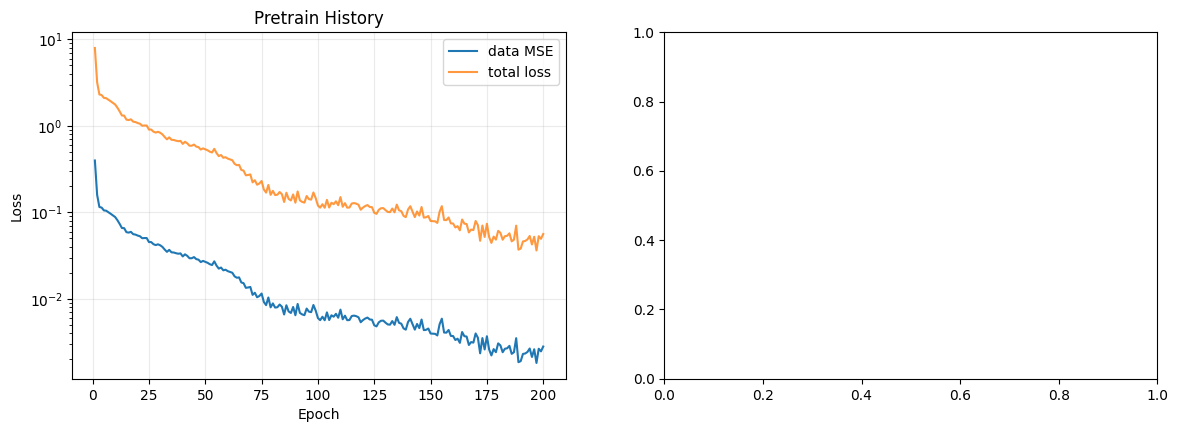

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(pretrain_history["epoch"], pretrain_history["loss_data"], label="data MSE", color="tab:blue")
axes[0].plot(pretrain_history["epoch"], pretrain_history["loss"], label="total loss", color="tab:orange", alpha=0.8)
axes[0].set_title("Pretrain History")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].plot(full_history["epoch"], full_history["loss"], label="total loss", color="black")
axes[1].plot(full_history["epoch"], full_history["loss_data"], label="data loss", color="tab:blue")
axes[1].plot(full_history["epoch"], full_history["loss_phys"], label="physics loss", color="tab:red")
axes[1].set_title("Full PINN History")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Pretrain checkpoint: {PRETRAIN_CKPT_PATH}")
print(f"Full-training checkpoint: {FULL_CKPT_PATH}")


In [27]:
import torch
import numpy as np

# Choose which stage to inspect: PRETRAIN_CKPT_PATH or FULL_CKPT_PATH.
CKPT_TO_LOAD = PRETRAIN_CKPT_PATH

model = build_model()
load_checkpoint_weights(model, CKPT_TO_LOAD)
model.eval()


MLP(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=100, bias=True)
    (1): AdaptiveSwish()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): AdaptiveSwish()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): AdaptiveSwish()
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): AdaptiveSwish()
    (8): Linear(in_features=100, out_features=100, bias=True)
    (9): AdaptiveSwish()
    (10): Linear(in_features=100, out_features=100, bias=True)
    (11): AdaptiveSwish()
    (12): Linear(in_features=100, out_features=4, bias=True)
  )
)

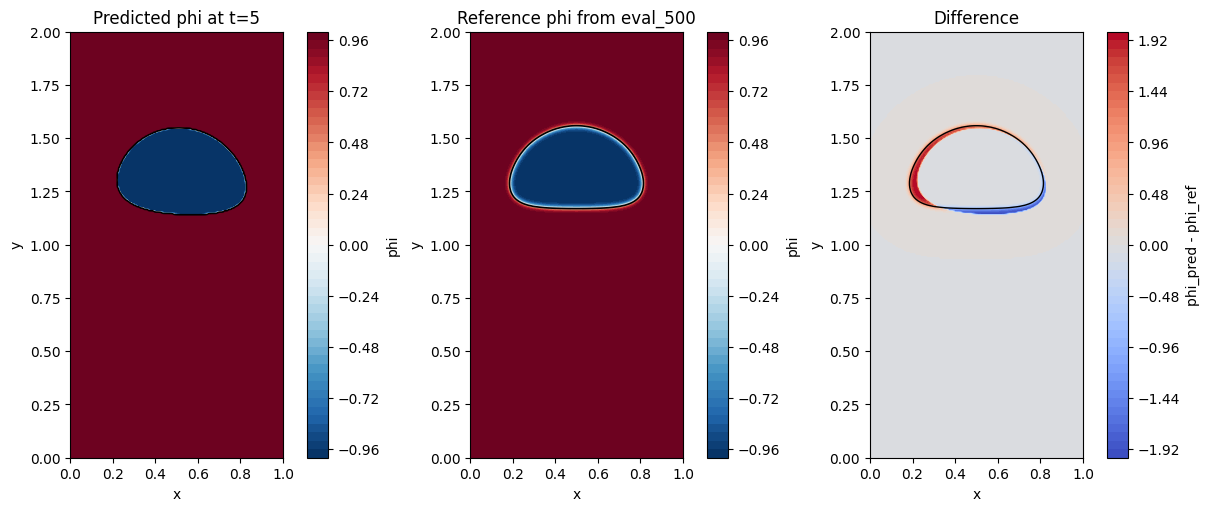

In [29]:
import numpy as np
import matplotlib.pyplot as plt
t_val = 5
eval_path = f"eval/eval_{t_val * 100}.csv"

# Choose which sharpness to use for inference.
# For the final model, the default is the end of the full-stage schedule.
S_EVAL = S_FULL_END

eval_df = pd.read_csv(eval_path)
eval_df = eval_df[np.isclose(eval_df["Time"].to_numpy(dtype=float), t_val)].copy()
if eval_df.empty:
    raise ValueError(f"No rows with Time={t_val} found in {eval_path}")

phi_ref_df = eval_df.pivot(index="Points:1", columns="Points:0", values="phi").sort_index().sort_index(axis=1)
x_vals = phi_ref_df.columns.to_numpy(dtype=float)
y_vals = phi_ref_df.index.to_numpy(dtype=float)
X_np, Y_np = np.meshgrid(x_vals, y_vals, indexing="xy")
phi_ref = phi_ref_df.to_numpy(dtype=float)

X = torch.as_tensor(X_np, device=DEVICE, dtype=DTYPE)
Y = torch.as_tensor(Y_np, device=DEVICE, dtype=DTYPE)
XYT = torch.stack(
    [X.reshape(-1), Y.reshape(-1), torch.full((X.numel(),), t_val, device=DEVICE, dtype=DTYPE)],
    dim=1,
)

with torch.no_grad():
    _, _, _, alpha_sdf = model_fields(model, XYT)
    phi_pred = np.tanh(S_EVAL * alpha_sdf.reshape(len(y_vals), len(x_vals)).detach().cpu().numpy())

phi_diff = phi_pred - phi_ref
diff_lim = np.max(np.abs(phi_diff))
diff_lim = max(diff_lim, 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(12, 5), constrained_layout=True)

cf0 = axes[0].contourf(X_np, Y_np, phi_pred, levels=60, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].contour(X_np, Y_np, phi_pred, levels=[0.0], colors="k", linewidths=1.2)
fig.colorbar(cf0, ax=axes[0], label="phi")
axes[0].set_title(f"Predicted phi at t={t_val}")

cf1 = axes[1].contourf(X_np, Y_np, phi_ref, levels=60, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].contour(X_np, Y_np, phi_ref, levels=[0.0], colors="k", linewidths=1.2)
fig.colorbar(cf1, ax=axes[1], label="phi")
axes[1].set_title(f"Reference phi from eval_{t_val * 100}")

cf2 = axes[2].contourf(X_np, Y_np, phi_diff, levels=60, cmap="coolwarm", vmin=-diff_lim, vmax=diff_lim)
axes[2].contour(X_np, Y_np, phi_ref, levels=[0.0], colors="k", linewidths=1.0)
fig.colorbar(cf2, ax=axes[2], label="phi_pred - phi_ref")
axes[2].set_title("Difference")

for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 2)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")

plt.show()



NameError: name 'full_history' is not defined

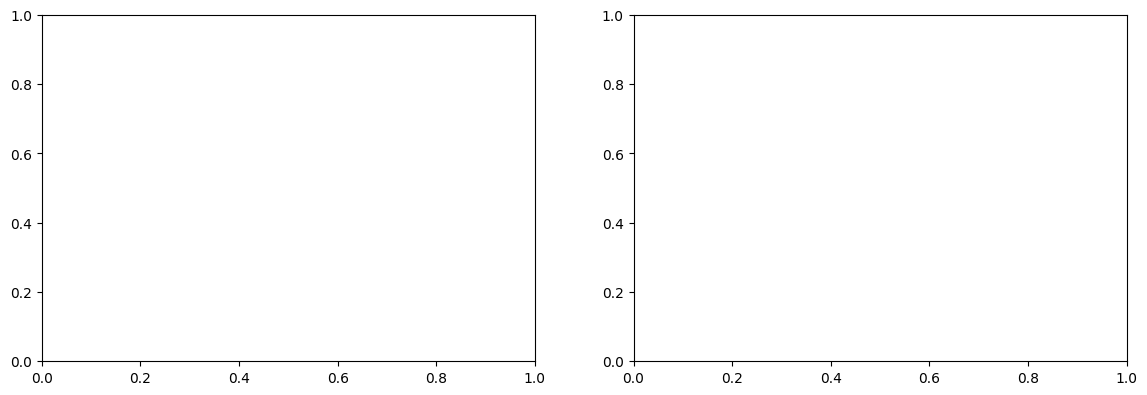

In [45]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(full_history["epoch"], full_history["L_div"], label="div")
axes[0].plot(full_history["epoch"], full_history["L_adv"], label="adv")
axes[0].plot(full_history["epoch"], full_history["L_mom"], label="mom")
axes[0].plot(full_history["epoch"], full_history["L_eik"], label="eik")
axes[0].set_title("Raw Physics Terms")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean Squared Residual")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].plot(full_history["epoch"], full_history["ema_div"], label="EMA div")
axes[1].plot(full_history["epoch"], full_history["ema_adv"], label="EMA adv")
axes[1].plot(full_history["epoch"], full_history["ema_mom"], label="EMA mom")
axes[1].plot(full_history["epoch"], full_history["ema_eik"], label="EMA eik")
axes[1].set_title("EMA Scales In Full PINN")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("EMA Value")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()
